# 02 — Feature Engineering
### Who Gets to Do Nothing? (Team #37)

**Goal:** Transform cleaned_EDA_data.csv into a clean model-ready feature matrix,
run correlation and VIF diagnostics, and save model_result.csv for Notebook 3.

**Input:** `cleaned_EDA_data.csv`
**Output:** `model_result.csv`, `age_mean.csv`

---

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

---
## Step 1 — Load the data

In [ ]:
final_df = pd.read_csv('cleaned_EDA_data.csv')
print(f'Rows: {len(final_df):,}  |  Columns: {final_df.shape[1]}')
final_df.head(3)

Rows: 145,248  |  Columns: 38


,TUCASEID,TRNUMHOU,TELFS,TRDPFTPT,TRERNWA,TUDIARYDAY,TRHOLIDAY,TRSPPRES,TESPEMPNOT,TRCHILDNUM,...,T120309,T120310,T120311,T120312,T120313,T120399,YEAR,TOTAL_LEISURE,RACE_LABEL,EDUC_LABEL
0,20100101100019,6,1,1,82400,1,0,3,-1,4,...,0,0,0,0,0,0,2010,0,Black,3_SomeCollege
1,20100101100020,2,1,1,58292,1,0,3,-1,1,...,0,0,0,0,0,0,2010,60,White,2_HS/GED
2,20100101100045,4,1,2,60000,3,0,1,1,1,...,0,0,0,0,0,0,2010,362,White,1_LessThanHS


In [ ]:
# Check which columns contain -1 values and how many
minus_one_counts = {}
for col in final_df.columns:
    count = (final_df[col] == -1).sum()
    if count > 0:
        minus_one_counts[col] = count

print(f'Columns with -1 values:\n')
for col, count in sorted(minus_one_counts.items(), key=lambda x: x[1], reverse=True):
    pct = count / len(final_df) * 100
    print(f'{col:<20} {count:>8,} rows  ({pct:.1f}%)')

Columns with -1 values:

TRYHHCHILD             88,031 rows  (60.6%)
TESCHENR               72,094 rows  (49.6%)
TESPEMPNOT             68,716 rows  (47.3%)
TRERNWA                68,040 rows  (46.8%)
TRDPFTPT               58,176 rows  (40.1%)
TEMJOT                 58,176 rows  (40.1%)
TRMJOCGR               58,175 rows  (40.1%)


---
## Step 2 — Feature Engineering

### 2a. Handling -1 values (ATUS structural blanks)

Per the ATUS data dictionary, -1 means Blank — the question was not asked
because it did not apply to that respondent due to survey routing. It is not a
missing response and rows should not be dropped.

In [ ]:
# Verify -1 counts before recoding
for col in ['TRERNWA','TRDPFTPT','TEMJOT','TESPEMPNOT','TRYHHCHILD']:
    n = (final_df[col] == -1).sum()
    print(f'{col}: {n:,} blank values (-1)')

TRERNWA: 68,040 blank values (-1)
TRDPFTPT: 58,176 blank values (-1)
TEMJOT: 58,176 blank values (-1)
TESPEMPNOT: 68,716 blank values (-1)
TRYHHCHILD: 88,031 blank values (-1)


### 2b. Binary recodes

In [ ]:
final_df['FEMALE'] = (final_df['TESEX'] == 2).astype(int)
final_df['PART_TIME'] = (final_df['TRDPFTPT'] == 2).astype(int)
final_df['MULTI_JOB'] = (final_df['TEMJOT']   == 1).astype(int)
print(f'Part-time: {final_df["PART_TIME"].sum():,} ({final_df["PART_TIME"].mean()*100:.1f}%)')
print(f'Multi-job: {final_df["MULTI_JOB"].sum():,} ({final_df["MULTI_JOB"].mean()*100:.1f}%)')

Part-time: 18,140 (12.5%)
Multi-job: 7,912 (5.4%)


### 2c. Earnings in dollars  

`TRERNWA` reports weekly earnings from a respondent’s main job, but it’s recorded in cents in the raw ATUS data. We divide it by 100 so it’s in dollars, which makes the coefficient easier to interpret — a one dollar increase in weekly earnings corresponds to a change of X minutes of leisure.

#### Handling the -1 values  

A value of -1 for `TRERNWA` means the question was never asked. This happens when the respondent is not employed or is self-employed, so the survey skips the earnings question entirely. The ATUS data dictionary confirms that this variable only applies to employed, non-self-employed individuals.

This creates a problem if we’re not careful. After converting values using `clip(lower=0)`, both someone who actually earns $0 and someone who isn’t employed at all would show up as having `EARNINGS = 0`. But those are very different situations.

To handle this, we add a separate indicator variable called `EARNINGS_MISSING`. This flag tells us whether the earnings value was truly zero or simply not applicable.

```python
final_df['EARNINGS_MISSING'] = (final_df['TRERNWA'] == -1).astype(int)
final_df['EARNINGS'] = final_df['TRERNWA'].clip(lower=0) / 100



In [ ]:
final_df['EARNINGS_MISSING'] = (final_df['TRERNWA'] == -1).astype(int)
final_df['EARNINGS'] = final_df['TRERNWA'].clip(lower=0) / 100
print(f'Earnings range: $0 – ${final_df["EARNINGS"].max():.0f}/week')
print(f'Zero (not applicable): {(final_df["EARNINGS"]==0).mean()*100:.1f}%')

Earnings range: $0 – $11953/week
Zero (not applicable): 47.0%


### 2e. Mean-centered age and quadratic term

Without centering, TEAGE and TEAGE² are highly correlated.

The EDA age curve shows leisure dips in mid-life and accelerates
in retirement. TEAGE_C_SQ lets OLS fit that curve rather than forcing a straight line.

In [ ]:
age_mean = final_df['TEAGE'].mean()
print(f'Sample mean age: {age_mean:.4f}')

final_df['TEAGE_C']    = final_df['TEAGE'] - age_mean
final_df['TEAGE_C_SQ'] = final_df['TEAGE_C'] ** 2

corr = final_df[['TEAGE_C','TEAGE_C_SQ']].corr().iloc[0,1]
print(f'Correlation TEAGE_C vs TEAGE_C_SQ after centering: {corr:.4f}  (was ~0.97 before)')

Sample mean age: 49.6865
Correlation TEAGE_C vs TEAGE_C_SQ after centering: 0.0373  (was ~0.97 before)


### 2f. Age × employment interaction

Tests whether the retirement leisure boost is larger for older workers who are
employed but absent (on leave, sick days) vs younger ones. Captures a nuance
in the age-employment relationship that main effects alone miss.

In [ ]:
final_df['TELFS_absent']     = (final_df['TELFS'] == 2).astype(int)
final_df['AGE_X_EMPLOYMENT'] = final_df['TEAGE_C'] * final_df['TELFS_absent']

### 2g. Race consolidation

Raw PTDTRACE has up to 26 codes, many with very few respondents. Including all
as separate dummies inflates the condition number dramatically. We consolidate
into 4 groups.

| RACE code | Label | PTDTRACE codes |
|---|---|---|
| 1 | White (baseline) | 1 |
| 2 | Black | 2 |
| 3 | Asian | 4 |
| 4 | Other / Multiracial | 3, 5+ |

In [ ]:
def consolidate_race(code):
    if code == 1:   return 1
    elif code == 2: return 2
    elif code == 4: return 3
    else:           return 4

final_df['RACE'] = final_df['PTDTRACE'].apply(consolidate_race)
race_labels = {1:'White',2:'Black',3:'Asian',4:'Other/Multiracial'}
print('Race group counts:')
print(final_df['RACE'].map(race_labels).value_counts())

Race group counts:
RACE
White                115629
Black                 20077
Asian                  6234
Other/Multiracial      3308
Name: count, dtype: int64


### 2h. Education consolidation

Raw PEEDUCA runs from 31 to 46. We group into 5 meaningful levels
with high school / GED (39) as the baseline.

| EDUC code | Label | PEEDUCA codes |
|---|---|---|
| 1 | Less than HS | < 39 |
| 2 | HS / GED (baseline) | 39 |
| 3 | Some college | 40–42 |
| 4 | Bachelor's | 43 |
| 5 | Graduate | 44–46 |

In [ ]:
def consolidate_educ(code):
    if code < 39:          return 1
    elif code == 39:       return 2
    elif 40 <= code <= 42: return 3
    elif code == 43:       return 4
    else:                  return 5

final_df['EDUC'] = final_df['PEEDUCA'].apply(consolidate_educ)
educ_labels = {1:'< HS',2:'HS/GED',3:'Some college',4:"Bachelor's",5:'Graduate'}
print('Education group counts:')
print(final_df['EDUC'].map(educ_labels).value_counts())

Education group counts:
EDUC
Some college    38952
HS/GED          35170
Bachelor's      32178
Graduate        21133
< HS            17815
Name: count, dtype: int64


### 2i. Interaction terms

FEMALE × TRCHILDNUM — the motherhood penalty.

child_x_nopartner - Tests whether solo parents
face a larger per-child leisure cost than partnered parents.

In [ ]:
final_df['TRSPPRES_nopartner']  = (final_df['TRSPPRES'] == 3).astype(int)
final_df['FEMALE_X_CHILDNUM']   = final_df['FEMALE']              * final_df['TRCHILDNUM']
final_df['CHILD_X_NOPARTNER']   = final_df['TRCHILDNUM']          * final_df['TRSPPRES_nopartner']

---
## Step 3 — Correlation Matrix (post-engineering)

Re-run correlation on the final continuous variables before one-hot encoding.
Any |r| > 0.7 between predictors is a multicollinearity concern.

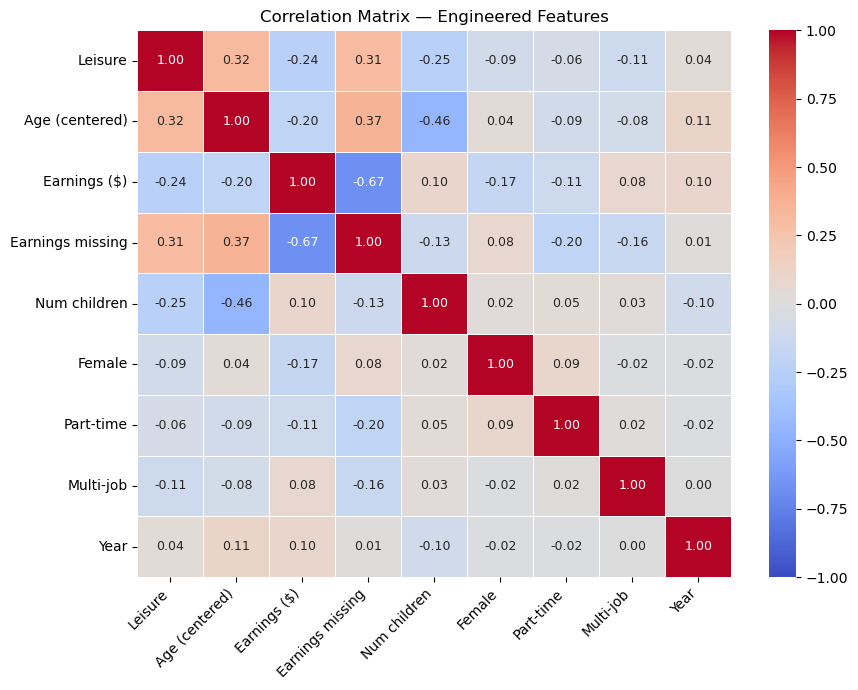

Predictor pairs with |r| > 0.5:
[('Earnings ($)', 'Earnings missing', np.float64(0.6721150971350317))]


In [ ]:
corr_cols2 = {
    'TOTAL_LEISURE':    'Leisure',
    'TEAGE_C':          'Age (centered)',
    'EARNINGS':         'Earnings ($)',
    'EARNINGS_MISSING': 'Earnings missing',
    'TRCHILDNUM':       'Num children',
    'FEMALE':           'Female',
    'PART_TIME':        'Part-time',
    'MULTI_JOB':        'Multi-job',
    'YEAR':             'Year'
}
corr2 = final_df[list(corr_cols2.keys())].rename(columns=corr_cols2).corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size':9}, ax=ax)
ax.set_title('Correlation Matrix — Engineered Features', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# Flag any high correlations between predictors
corr_pred = corr2.drop(index='Leisure', columns='Leisure').abs()
high = [(corr_pred.index[i], corr_pred.columns[j], corr_pred.iloc[i,j])
        for i in range(len(corr_pred)) for j in range(i+1,len(corr_pred.columns))
        if corr_pred.iloc[i,j] > 0.5]
print('Predictor pairs with |r| > 0.5:')
print(high if high else 'None — no high pairwise correlations.')

---
## Step 4 — Build Feature Matrix

One-hot encode categorical variables with `drop_first=True` to avoid the
dummy variable trap.

TRNUMHOU is excluded as VIF=13.8, p=0.071 in prior runs, caused by
correlation with `TRCHILDNUM`. Dropping it resolves multicollinearity.

| Variable | Baseline |
|---|---|
| `TELFS` | 1 — Employed at work |
| `TUDIARYDAY` | 1 — Sunday |
| `TRSPPRES` | 1 — Spouse present |
| `YEAR` | 2010 |
| `RACE` | 1 — White |
| `EDUC` | 2 — HS / GED |

In [ ]:
categorical_cols = ['TELFS','TUDIARYDAY','TRSPPRES','YEAR','RACE','EDUC']

df_model = pd.get_dummies(
    final_df[[
        'TEAGE_C','TEAGE_C_SQ','TRHOLIDAY','EARNINGS','EARNINGS_MISSING','TRCHILDNUM',
        'FEMALE','PART_TIME','MULTI_JOB',
        'FEMALE_X_CHILDNUM','AGE_X_EMPLOYMENT','CHILD_X_NOPARTNER',
        'TELFS','TUDIARYDAY','TRSPPRES','YEAR','RACE','EDUC',
        'TOTAL_LEISURE'
    ]],
    columns=categorical_cols,
    drop_first=True
).astype(float)

print(f'Total features: {df_model.shape[1]-1}')
print(f'Rows: {len(df_model):,}')
print(f'\nColumns: {df_model.columns.tolist()}')

Total features: 44
Rows: 145,248

Columns: ['TEAGE_C', 'TEAGE_C_SQ', 'TRHOLIDAY', 'EARNINGS', 'EARNINGS_MISSING', 'TRCHILDNUM', 'FEMALE', 'PART_TIME', 'MULTI_JOB', 'FEMALE_X_CHILDNUM', 'AGE_X_EMPLOYMENT', 'CHILD_X_NOPARTNER', 'TOTAL_LEISURE', 'TELFS_2', 'TELFS_3', 'TELFS_4', 'TELFS_5', 'TUDIARYDAY_2', 'TUDIARYDAY_3', 'TUDIARYDAY_4', 'TUDIARYDAY_5', 'TUDIARYDAY_6', 'TUDIARYDAY_7', 'TRSPPRES_2', 'TRSPPRES_3', 'YEAR_2011', 'YEAR_2012', 'YEAR_2013', 'YEAR_2014', 'YEAR_2015', 'YEAR_2016', 'YEAR_2017', 'YEAR_2018', 'YEAR_2019', 'YEAR_2021', 'YEAR_2022', 'YEAR_2023', 'YEAR_2024', 'RACE_2', 'RACE_3', 'RACE_4', 'EDUC_2', 'EDUC_3', 'EDUC_4', 'EDUC_5']


---
## Step 5 — VIF Check


VIF > 10 is problematic. VIF 5–10 is worth watching. VIF < 5 is fine.

In [ ]:
X_check = sm.add_constant(df_model.drop(columns='TOTAL_LEISURE'))
vif_data = pd.DataFrame({
    'feature': X_check.columns,
    'VIF': [variance_inflation_factor(X_check.values.astype(float), i)
            for i in range(X_check.shape[1])]
}).query('feature != "const"').sort_values('VIF', ascending=False)

high_vif = vif_data[vif_data['VIF'] > 5]
if high_vif.empty:
    print('All VIF < 5.')
else:
    print(f'{len(high_vif)} features with VIF > 5:')
    print(high_vif.to_string(index=False))

print('\nAge terms after centering:')
print(vif_data[vif_data['feature'].isin(['TEAGE_C','TEAGE_C_SQ'])].to_string(index=False))

print('\nFull VIF table:')
print(vif_data.to_string(index=False))

2 features with VIF > 5:
         feature      VIF
EARNINGS_MISSING 5.295708
         TELFS_5 5.172166

Age terms after centering:
   feature      VIF
   TEAGE_C 1.730825
TEAGE_C_SQ 1.439876

Full VIF table:
          feature      VIF
 EARNINGS_MISSING 5.295708
          TELFS_5 5.172166
       TRCHILDNUM 3.036263
FEMALE_X_CHILDNUM 2.898403
           EDUC_4 2.665929
           EDUC_3 2.662747
           EDUC_2 2.536153
         EARNINGS 2.487670
           EDUC_5 2.351170
CHILD_X_NOPARTNER 1.968042
        YEAR_2011 1.774847
        YEAR_2012 1.773884
          TEAGE_C 1.730825
        YEAR_2014 1.728022
        YEAR_2013 1.714687
        YEAR_2015 1.689817
        YEAR_2016 1.667508
        YEAR_2017 1.653174
          TELFS_4 1.627905
        YEAR_2018 1.619115
       TRSPPRES_3 1.617672
        YEAR_2019 1.612019
        YEAR_2021 1.597343
        YEAR_2023 1.577386
        YEAR_2022 1.546255
        YEAR_2024 1.530908
           FEMALE 1.496356
     TUDIARYDAY_7 1.471476
       TE

Two variables show VIF marginally above 5: EARNINGS_MISSING (5.30) and TELFS_5 (5.17). This is expected given their structural relationship: non-employed respondents drive both variables simultaneously. As both carry distinct information and their VIF values are only marginally above the conservative threshold, they were retained in the model.

---
## Step 6 — Save outputs

In [ ]:
df_model.to_csv('model_result.csv', index=False)
pd.Series({'age_mean': age_mean}).to_csv('age_mean.csv')

print(f'Saved: model_result.csv  ({df_model.shape[0]:,} rows, {df_model.shape[1]} columns)')
print(f'Saved: age_mean.csv  (age_mean = {age_mean:.4f})')

Saved: model_result.csv  (145,248 rows, 45 columns)
Saved: age_mean.csv  (age_mean = 49.6865)
